<a href="https://colab.research.google.com/github/Notmefrfr/Notmefrfr/blob/latihan/Lat_ComBio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install BioPython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 22.1 MB/s eta 0:00:00


In [3]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqUtils import *
from collections import Counter
import matplotlib.pyplot as plt


In [4]:
seq1 = SeqIO.read('sequence.fasta','fasta').seq
seq2 = SeqIO.read('sequence2.fasta','fasta').seq

print(len(seq1))
print(len(seq2))
print(seq1[:10])
print(seq2[-20:][::-1])

74
300
ACAAGAAGGG
AGGGTCGCAGGGACGGTCCA


In [5]:
seq3 = seq1[:10] + seq2[-20:][::-1]
print(seq3)

ACAAGAAGGGAGGGTCGCAGGGACGGTCCA


In [7]:
print('Count of A in Seq1 = ', seq1.count('A'))
print(seq1.split('GCA'))
print(seq1.find('G'))
print(seq1.index('G'))

Count of A in Seq1 =  27
[Seq('ACAAGAAGGGAGGAGAGAAAAGCCATGGCCGACAAGGTCCTGAAGGAGAAGAGA...CAT')]
4
4


In [8]:
subSeq = Seq('GCA')

result = nt_search(str(seq1), str(subSeq))
print(result)

['GCA']


Counter({'A': 27, 'G': 23, 'C': 13, 'T': 11})


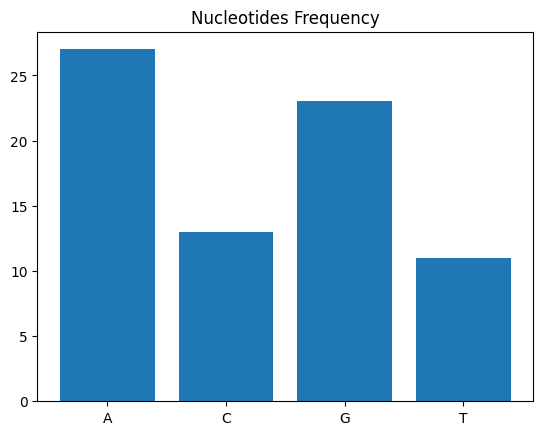

In [9]:
from collections import Counter
import matplotlib.pyplot as plt

freq = Counter(seq1)
print(freq)
freq_key = freq.keys()
freq_values = freq.values()

# Plotting
plt.bar(freq_key, freq_values)
plt.title('Nucleotides Frequency')
plt.show()

In [10]:


#e
print("GC:",gc_fraction(seq1))
print("AT:",1-gc_fraction(seq1))


GC: 0.4864864864864865
AT: 0.5135135135135135


In [12]:
from Bio.SeqUtils import MeltingTemp

sequence1 = Seq('ATGCTAGCACTACGTATGCGATCGATCGGACGTCGACT')
sequence2 = Seq('ACGTATGCGATCGATCGATGCTAGCACTGACGTCGACT')

# Wallace Rule
print(MeltingTemp.Tm_Wallace(sequence1))
print(MeltingTemp.Tm_Wallace(sequence2))

# GC Content
print(MeltingTemp.Tm_GC(sequence1))
print(MeltingTemp.Tm_GC(sequence2))

# NN -> Nearest Neighbour
print(MeltingTemp.Tm_NN(sequence1))
print(MeltingTemp.Tm_NN(sequence2))

116.0
116.0
65.69237575618844
65.69237575618844
68.01997850002317
68.27940271592348


In [15]:
# Nucleotide Molecular Weight


print(molecular_weight(seq2))


93579.85469999988


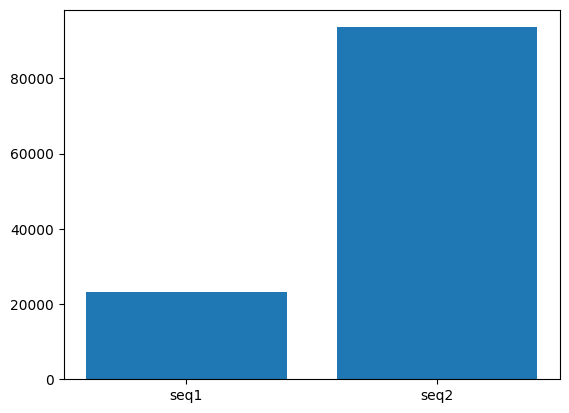

In [14]:
values = (molecular_weight(seq1), molecular_weight(seq2))
x= ("seq1","seq2")
plt.bar(x,values)
plt.show;

In [17]:
mrnaseq1 = seq1.transcribe()    # <-- parentheses to call the method
mrnaseq2 = seq2.transcribe()

print(mrnaseq1)
print(" ")
print(mrnaseq2)

poldna1 = seq1.translate()
poldna2 = seq2.translate()
print(" ")
print(poldna1)
print(" ")
print(poldna2)


ACAAGAAGGGAGGAGAGAAAAGCCAUGGCCGACAAGGUCCUGAAGGAGAAGAGAAAGCUGUUUAUCCGUUCCAU
 
AGUUUCAGUCACACAAGAAGGGAGGAGAGAAAAGCCAUGGCCGACAAGGUCCUGAAGGAGAAGAGAAAGCUGUUUAUCCGUUCCAUGGGUGAAGGUACAAUAAAUGGCUUACUGGAUGAAUUAUUACAGACAAGGGUGCUGAACAAGGAAGAGAUGGAGAAAGUAAAACGUGAAAAUGCUACAGUUAUGGAUAAGACCCGAGCUUUGAUUGACUCCGUUAUUCCGAAAGGGGCACAGGCAUGCCAAAUUUGCAUCACAUACAUUUGUGAAGAAGACAGUUACCUGGCAGGGACGCUGGGA
 
TRREERKAMADKVLKEKRKLFIRS
 
SFSHTRREERKAMADKVLKEKRKLFIRSMGEGTINGLLDELLQTRVLNKEEMEKVKRENATVMDKTRALIDSVIPKGAQACQICITYICEEDSYLAGTLG


/usr/local/lib/python3.11/dist-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [24]:
from Bio.SeqUtils import seq3 # seq3 untuk translate protein jadi 3 huruf pertama
DNAsequence = Seq('GATCGATGTTGCACAGCCGTAAAAATCGGT')
protein = DNAsequence.translate()
protein_3 = seq3(protein)
print(DNAsequence)
print(protein)

GATCGATGTTGCACAGCCGTAAAAATCGGT
DRCCTAVKIG


In [26]:
print(Counter(seq1))

Counter({'A': 27, 'G': 23, 'C': 13, 'T': 11})


In [63]:
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

alignment = pairwise2.align.localxx(seq1,seq2)

for x in alignment:
  print(x)

for x in alignment:
  print(format_alignment(*x))


Streaming output truncated to the last 5000 lines.
|||||||. |.| ||||||||||||. |  | |||||||||||||||||||   |  | ||||||   |  | ||||||||             |||||||||||||||||||||||||||||||||||||       |    | |||||||||||||    |           | ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||    ||   |     |||||||||||||||||||||||||||||||||||||           | |||   | ||
ID: AU09-8419.1
Name: AU09-8-419.1
Description: AU0--98-419.1 AU0--98-419 Sugano Homo sapiens cDNA library Homo sapiens cDNA clone ----CAS0--3528 5' similar t----------------o- Homo sapien interleukin-1 beta convertase (IL1BCE) mRNA, mRNA sequence
Number of features: 0
Seq('AGTTTCAGTCACACAAGAAGGGAGGAGAGAAAAGCCATGGCCGACAAGGTCCT-----------G-...-GGA-')
  Score=260

ID: AU076-8-11-.1
Name: AU07681-1-.1
Description: AU076-81-1-.1 AU076-81-1- Sugano -------------cDNA library Homo sapiens cDNA clone kaia---097--2- 5' similar to 5'-end region of Homo sapien interleukin-1 beta convertase (IL1BCE) mR

In [65]:
def hamming(seq1,seq2):
  h = []
  for (x,y) in zip(seq1,seq2):
    if x!=y:
      h.append((x,y))
  return len(h)

print(hamming(sequence1,sequence2))


18


In [61]:
!pip install python-Levenshtein


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.0 MB/s eta 0:00:00


In [62]:
import Levenshtein

print(Levenshtein.distance(sequence1, sequence2))


13
